# Chorus — a quantitative teardown 🔬
### Standalone-vs-combo Sharpe · the correlation matrix · the breadth (√k) sweep · equal-wt vs risk-parity · the cost wall

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Whole > parts?: Mixed](https://img.shields.io/badge/Whole_%3E_parts%3F-Mixed-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim with its number.* The steelman: per the Fundamental Law (IR ≈ IC·√breadth), blending several weak decorrelated alphas beats any component. We confirm the *mechanism* is `REAL` (components −0.03 correlated; momentum+reversal 0.66 > both parts) but rate the assembled signal `WEAK` (the naive chorus flattens to 0.00 once a negative-IC voice is added), `MIRAGE` net (break-even 0.02 bp), and the headline whole-greater-than-parts `MIXED`.

> ⚠️ **Not investment advice.** The core executes on a synthetic three-component panel; the real S&P 500 run is in [`../docs/results.md`](../docs/results.md), sources in [`../docs/references.md`](../docs/references.md). The real panel is current-membership ⇒ survivorship bias (and low-vol is the most survivorship-sensitive leg).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from chorus import data, signals, strategy, costs, extension

# Offline synthetic control: a panel carrying three weak, decorrelated components (the machinery) + a null.
# The real S&P 500 verdict is in ../docs/results.md.
r, _, truth = data.synthetic_panel(combo_strength=1.0, seed=38)
r0, _, _ = data.synthetic_panel(combo_strength=0.0, seed=38)
sig = signals.all_signals(r); sig0 = signals.all_signals(r0)
print(f"synthetic control: {truth.n_stocks} stocks x {truth.n_bars} days, combo_strength {truth.combo_strength} (null=0)")


synthetic control: 150 stocks x 4032 days, combo_strength 1.0 (null=0)


## Beat 0 · Verdict

| Axis | Stamp | Why |
|---|---|---|
| **Signal** — diversification edge real? | 🟡 `WEAK` | Mechanism real (corr **-0.03**; momentum+reversal **0.66** > parts) but the naive chorus is **0.00** gross. |
| **Tradability** | 🔴 `MIRAGE` | Turnover **0.38**/day ⇒ break-even **0.02 bp**; net-negative at any real cost. |
| **Whole > parts?** | 🟡 `Mixed` | Confirmed for a decorrelated pair, not for the all-in blend. |

> **In one sentence:** combining weak decorrelated alphas really can out-sing every soloist — the momentum+reversal pair does — but breadth multiplies *information*, so a decorrelated negative-IC voice subtracts, and the assembled chorus is real to measure, a mirage to trade.

*(This notebook executes on the synthetic control; the real numbers are in [`../docs/results.md`](../docs/results.md).)*

## Beat 1 · The claim, precisely

Let $w^{(k)}_{i,t}$ be component $k$'s weight on stock $i$ (each dollar-neutral $\sum_i w^{(k)}_{i,t}=0$, gross-1 $\sum_i|w^{(k)}_{i,t}|=1$, lagged one day). The combo is $w_{i,t}\propto\sum_k a_k\,w^{(k)}_{i,t}$, renormalised to gross 1, with $a_k=1$ (equal-weight) or $a_k=1/\sigma_k$ (inverse-vol). The Fundamental Law (Grinold 1989): $\text{IR}\approx \text{IC}\cdot\sqrt{\text{breadth}}$ — for $N$ *independent*, *positive-IC* bets the combo IR is $\sqrt N$ the average single-bet IR. Null: i.i.d. returns ⇒ every component and the combo earn nothing.

In [2]:
print('control — standalone vs combo (gross):')
display(costs.standalone_vs_combo(sig, r, cost_bps=0.0).round(3))
print('null — every book ~0:')
display(costs.standalone_vs_combo(sig0, r0, cost_bps=0.0).round(3))

control — standalone vs combo (gross):


,sharpe,cagr,vol_ann,turnover
book,,,,
momentum,1.495,0.043,0.028,0.086
reversal,2.081,0.063,0.030,0.641
low_vol,1.187,0.034,0.029,0.061
COMBO (equal-wt),2.705,0.082,0.029,0.377
COMBO (risk-parity),2.259,0.069,0.030,0.441


null — every book ~0:


,sharpe,cagr,vol_ann,turnover
book,,,,
momentum,0.089,0.002,0.028,0.087
reversal,0.104,0.003,0.028,0.631
low_vol,-0.009,-0.001,0.025,0.046
COMBO (equal-wt),0.095,0.002,0.027,0.371
COMBO (risk-parity),0.064,0.001,0.027,0.418


> 💡 **In plain words.** On the control the three voices each carry real, independent edge (Sharpe ~1.49/2.08/1.19), the combo lifts to **2.71** above every soloist, at correlation **+0.02**; on the null all of it is ~0. The apparatus harvests breadth when it's there — so the real-tape result is about the *market*.

## Beat 2 · So what?

Markowitz (1952): combining imperfectly-correlated return streams is the one free lunch in finance. Grinold-Kahn (1999) turn it into an engineering rule — IR = IC·√breadth·(transfer coefficient) — and Clarke-de Silva-Thorley (2002) add the fine print that real constraints (neutrality, turnover) erode how much you keep. Pre-registered prediction: the *mechanism* shows up (decorrelated components, a pair that beats its parts), but the captured IR is small and dies on cost — and a negative-IC component, however decorrelated, hurts. Beats 4–7 test it.

## Beat 3 · Pre-registered protocol

1. **Diversify?** `strategy.avg_pairwise_corr` + `costs.correlation_matrix`.
2. **Whole > parts?** `costs.standalone_vs_combo` (each component vs equal-wt & risk-parity).
3. **Breadth law?** `extension.breadth_sweep` (Sharpe vs # signals, against √k).
4. **Scheme?** `extension.scheme_comparison` (equal vs inverse-vol).
5. **Tradable?** `strategy.turnover`, `costs.breakeven_cost_bps`, `costs.cost_sweep`.

**Mirage line:** combo gross Sharpe ≤ best component, *or* break-even cost below realistic equity costs.

## Beat 4 · The teardown

### 4a · Decorrelation + the breadth lift (the mechanism)

control correlation matrix:


,momentum,reversal,low_vol
momentum,1.000,-0.020,0.071
reversal,-0.020,1.000,0.014
low_vol,0.071,0.014,1.000


,components,sharpe,sharpe_ratio_to_1,sqrt_k
n_signals,,,,
1,momentum,1.495,1.000,1.000
2,"momentum, reversal",2.566,1.717,1.414
3,"momentum, reversal, low_vol",2.705,1.810,1.732


Text(0.5, 1.0, 'Breadth lift (synthetic control)')

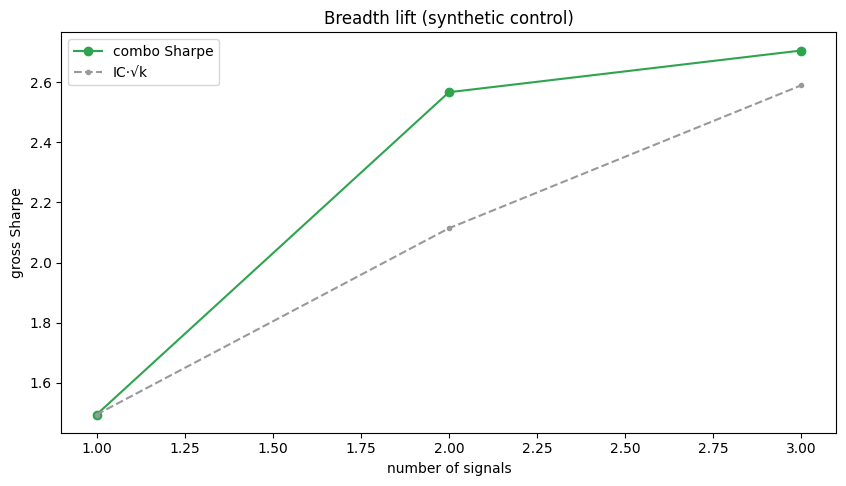

In [3]:
print('control correlation matrix:'); display(costs.correlation_matrix(sig, r).round(3))
bs = extension.breadth_sweep(sig, r)
display(bs.round(3))
fig, ax = plt.subplots()
ax.plot(bs.index, bs['sharpe'], marker='o', color='#2ea44f', label='combo Sharpe')
ax.plot(bs.index, bs['sharpe'].iloc[0]*bs['sqrt_k'], marker='.', ls='--', color='#999', label='IC·√k')
ax.set_xlabel('number of signals'); ax.set_ylabel('gross Sharpe'); ax.legend(); ax.set_title('Breadth lift (synthetic control)')

> 💡 **In plain words.** The components barely correlate, so stacking them concentrates signal and cancels noise — the combo Sharpe tracks the √k line. That's the engine. The question is whether the *real* components feed it good fuel.

### 4b · The real tape — `MIXED`, and why (the central result)

In [4]:
print('Real tape (../docs/results.md):')
print('  standalone gross Sharpe:  momentum 0.36   reversal 0.64   low-vol -0.89')
print('  avg pairwise correlation: -0.03  (decorrelated as promised)')
print('  PAIR momentum+reversal:   0.66   (> both parts -> whole > parts CONFIRMED)')
print('  PAIR momentum+low-vol:    -0.37')
print('  PAIR reversal+low-vol:    -0.29')
print('  naive 3-signal combo:     equal 0.00   risk-parity -0.15')
print('  -> the negative-IC low-vol leg sinks the naive chorus: breadth x IC needs IC>0 everywhere')

Real tape (../docs/results.md):
  standalone gross Sharpe:  momentum 0.36   reversal 0.64   low-vol -0.89
  avg pairwise correlation: -0.03  (decorrelated as promised)
  PAIR momentum+reversal:   0.66   (> both parts -> whole > parts CONFIRMED)
  PAIR momentum+low-vol:    -0.37
  PAIR reversal+low-vol:    -0.29
  naive 3-signal combo:     equal 0.00   risk-parity -0.15
  -> the negative-IC low-vol leg sinks the naive chorus: breadth x IC needs IC>0 everywhere


> 💡 **In plain words.** The Law isn't broken — it's read carefully. Sharpe ≈ IC·√breadth, so adding a *decorrelated* bet with **negative** IC multiplies a negative number by 1/√N and *subtracts* from the combo. Diversification is addition of expected returns, not magic.

## Beat 5 · The verdict

- **`WEAK`** (4a/4b): mechanism real on control (2.71>soloists) and for the real momentum+reversal pair (0.66), but the assembled real chorus is 0.00.
- **`MIRAGE`** (Beat 6): break-even 0.02 bp, turnover 0.38/day.
- **Whole > parts `MIXED`**: confirmed for a curated decorrelated pair, not the naive blend.

> **Signal `WEAK` · Tradability `MIRAGE` · Whole > parts? `MIXED`** — the capstone lesson with its fine print: the edge is diversification, but only over bets that are individually right.

## Beat 6 · Could you trade it?

- **Not as shown.** The combo inherits the reversal leg's churn (turnover 0.38/day) ⇒ break-even 0.02 bp — gone net of any realistic equity cost.
- **The healthy pair is thin.** momentum+reversal nets ~0.51 at 1 bp; with survivorship bias the honest expectation is lower.
- **Capacity & method.** The deliverable is the *method* (and its fine print), not a book: blend decorrelated alphas, but screen each for positive expectancy first (Clarke-de Silva-Thorley transfer-coefficient erosion does the rest).

## Beat 7 · Going further

### 7a · Worked complement — breadth is the lever, the scheme is not ([`../docs/extension.md`](../docs/extension.md))
Two follow-ups: how Sharpe scales with the *number* of components (√breadth), and equal-weight vs inverse-vol. Synthetic here; real tape in [`../docs/extension.md`](../docs/extension.md).

Real breadth sweep (gross Sharpe, ../docs/extension.md):
  1 signal 0.36  ->  2 signals 0.66  ->  3 signals 0.00 (off-key 3rd voice)

Real scheme comparison (../docs/results.md):
  equal-weight 0.00   risk-parity -0.15  (the blend is NOT the lever)


,sharpe,cagr,vol_ann
scheme,,,
equal,2.705,0.082,0.029
risk_parity,2.259,0.069,0.030


Text(0.5, 1.0, 'Breadth sweep — control rises monotonically')

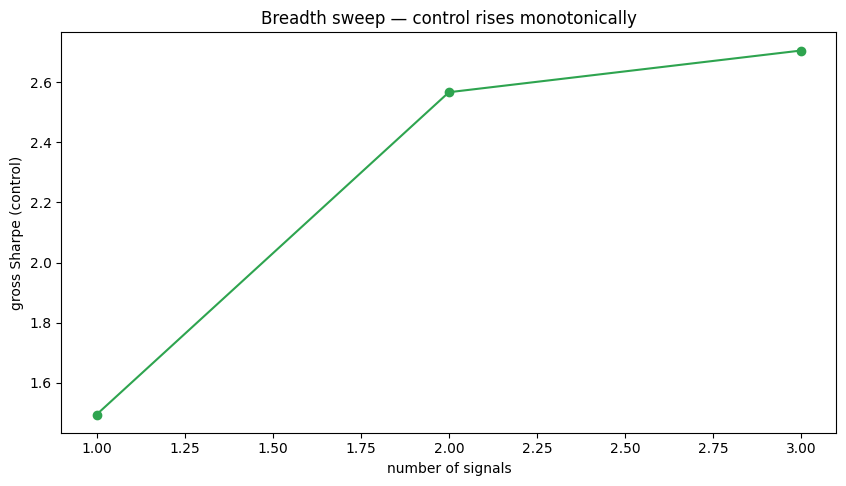

In [5]:
print('Real breadth sweep (gross Sharpe, ../docs/extension.md):')
print('  1 signal 0.36  ->  2 signals 0.66  ->  3 signals 0.00 (off-key 3rd voice)')
print('\nReal scheme comparison (../docs/results.md):')
print('  equal-weight 0.00   risk-parity -0.15  (the blend is NOT the lever)')
sc = extension.scheme_comparison(sig, r)
display(sc.round(3))
fig, ax = plt.subplots(); bs = extension.breadth_sweep(sig, r)
ax.plot(bs.index, bs['sharpe'], marker='o', color='#2ea44f')
ax.set_xlabel('number of signals'); ax.set_ylabel('gross Sharpe (control)'); ax.set_title('Breadth sweep — control rises monotonically')

> 💡 **In plain words.** On the real tape Sharpe rises 1→2 signals (~√2, as the Law says) then *collapses* at 3 because the third voice is a loser; inverse-vol weighting can't save it (it actually over-weights the low-turnover, off-key leg). Pick the roster, not the knob.

### 7b · What the pair of controls proves & other forks
The synthetic best-case (chorus 2.71 > every soloist) and the real honest-case (mechanism fires for the right pair, fails for the naive blend) bracket §3.20 exactly: **diversification across decorrelated alphas is real and is the closest thing to a free lunch — but it is addition of expected returns, not alchemy.** Full runs in [`../docs/results.md`](../docs/results.md) and [`../docs/extension.md`](../docs/extension.md).

### Forks
- **Sign-screened breadth** — admit a component only if its trailing OOS Sharpe is positive.
- **Wider roster** — carry, quality, seasonality (Studies 18/19/28); does √breadth keep rising?
- **Optimised combine** — a shrunk mean-variance blend of the alpha streams (§3.18) vs the naive weights, net of estimation error.

PRs welcome — screen by sign, widen the chorus, or try an optimised combine.